In [9]:
import numpy as np
import pickle
import experiments.build_NYC_subway_net as nyc
demand = np.load("full_demand.npy")
with open("data/gml/NYC_small_demands.gpickle", 'rb') as f:
    g = pickle.load(f)
with open("data/gml/NYC.gpickle", 'rb') as f:
    graph = pickle.load(f)
tNet, tstamp, fcoeffs = nyc.build_NYC_net(
            "data/net/NYC/", only_road=True
        )

In [12]:

nonzero = np.nonzero(demand)
print(nonzero[0])
print(np.unique(nonzero[0]))
print(np.unique(nonzero[1]))
print(np.max(demand))
print(np.min(demand[nonzero]))


[  27   27   27 ... 1017 1017 1017]
[  27   31   41   47   55   74   83  124  150  159  167  172  196  238
  253  265  329  338  341  347  356  385  396  410  441  449  457  475
  509  520  528  532  552  556  583  598  614  621  629  657  695  712
  715  728  736  745  768  777  793  832  849  879  891  901  920 1015
 1017]
[  27   31   41   47   55   74   83  124  150  159  167  172  196  238
  253  265  329  338  341  347  356  385  396  410  441  449  457  475
  509  520  528  532  552  556  583  598  614  621  629  657  695  712
  715  728  736  745  768  777  793  832  849  879  891  901  920 1015
 1017]
232.00934302501847
7.349190512297126e-05


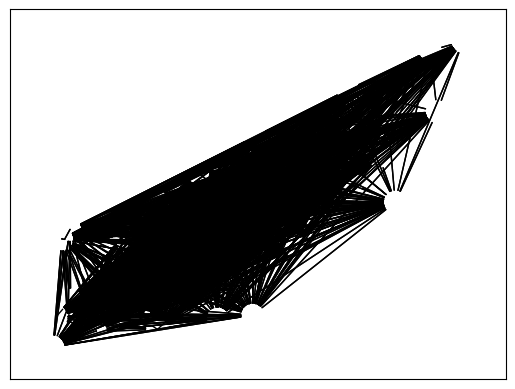

In [22]:
import networkx as nx
import matplotlib.pyplot as plt
tNet.read_node_coordinates("data/pos/NYC.txt")
nodelist = list(tNet.G.nodes())
orig = [nodelist[i] for i in nonzero[1]]
dest = [nodelist[i] for i in nonzero[0]]
dem = {}
for i in range(len(orig)):
    dem[orig[i], dest[i]] = demand[nonzero[0].astype(int)[i], nonzero[1].astype(int)[i]]
positions = [d['pos'] for u,d in tNet.G.nodes(data=True)]


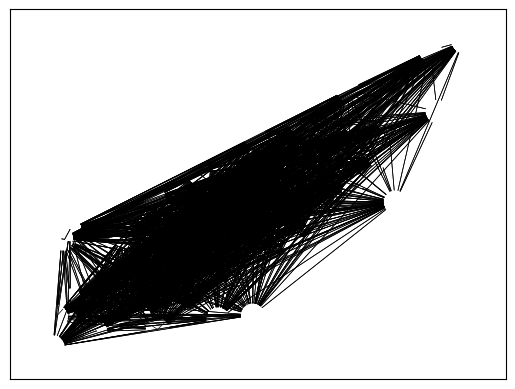

In [24]:
nx.draw_networkx_edges(tNet.G, positions, edgelist=dem.keys(), arrowsize=0.5, arrowstyle= '-', width=0.5)
plt.show()